In [22]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Experiments

## Network Class

In [23]:
class SimpleNet:

    # Initialise network parameters
    def __init__(self, N):
        self.W = [1] * N
        self.B = [0] * N
        self.A = [1] * N
        self.N = N

    # Forward pass on single value
    # Added optional n to only sum first n neurons
    def forward(self, x, n = None):
        
        # Load network parameters
        W, B, A, N = self.W, self.B, self.A, self.N

        # Optionally set N to n
        if n is not None:
            N = n

        # Calculate & sum ReLUs
        y = 0
        for i in range(N):
            y += A[i] * max(0, W[i] * x + B[i])
            
        return y

    # Plot network for specified range
    # Added optional n to only plot first n neurons
    def plot(self, start = -10, stop = 10, n = None, res = 10):

        # Calculate values for range
        x = np.linspace(start, stop, abs(start) * res + abs(stop) * res + 1)
        y = [self.forward(point, n) for point in x]

        # Load network parameters
        W, B, A, N = self.W, self.B, self.A, self.N

        # Create title string
        title = f"Network: {N} neuron(s)"
        for i in range(N):
            title += f"\nw{i + 1:2} = {W[i]:3},   b{i + 1:2} = {B[i]:3},   a{i + 1:2} = {A[i]:3}"
        
        # Plot graph
        plt.figure()
        plt.plot(x, y)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(title)
        plt.show()

## Single ReLU examples

The default values produce a regular ReLU

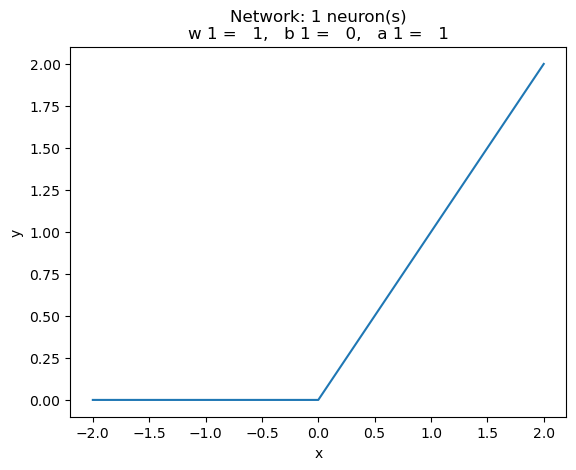

In [24]:
# ReLU function
net = SimpleNet(1)
net.plot(-2, 2)

Flipping the sign of the input weight mirrors the ReLU Horizontally

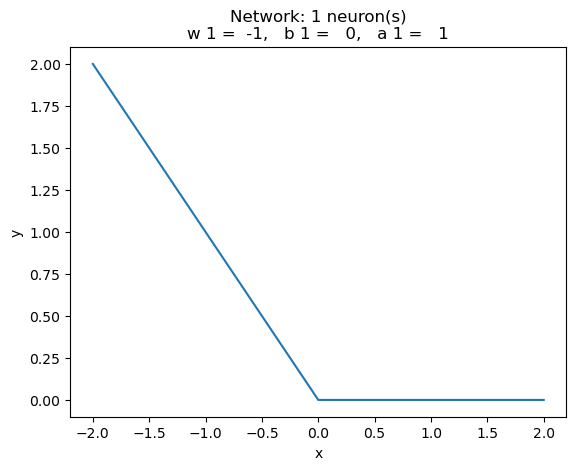

In [25]:
# Mirrored (H) ReLU function
net = SimpleNet(1)
net.W = [-1]
net.plot(-2, 2)

Flipping the sign of the output weight mirrors the ReLU vertically

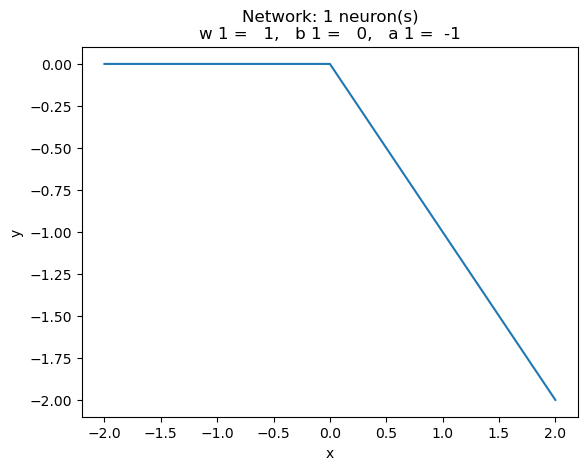

In [26]:
# Mirrored (V) ReLU function
net = SimpleNet(1)
net.A = [-1]
net.plot(-2, 2)

Increasing the bias moves the ReLU to the left

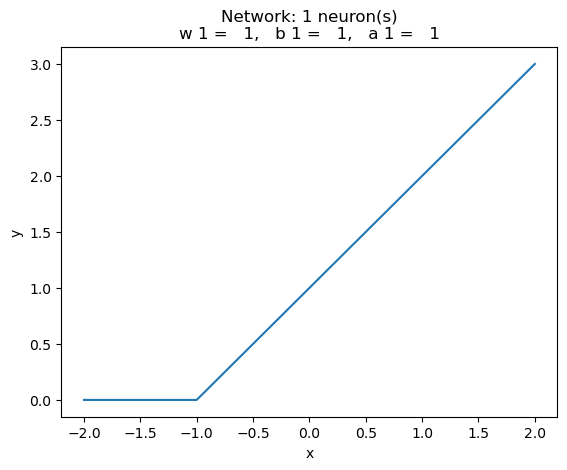

In [27]:
# Shifted ReLU function
net = SimpleNet(1)
net.B = [1]
net.plot(-2, 2)

For scaled ReLUs the shift needs to be increased

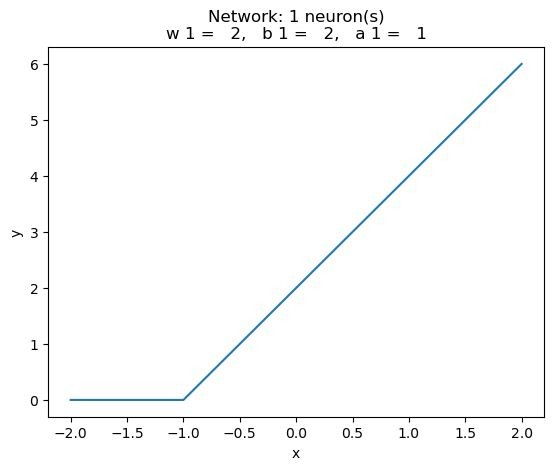

In [28]:
# Shifted ReLU function
net = SimpleNet(1)
net.W = [2]
net.B = [2]
net.plot(-2, 2)

The shift from the bias is ALSO mirrored (horizontally)

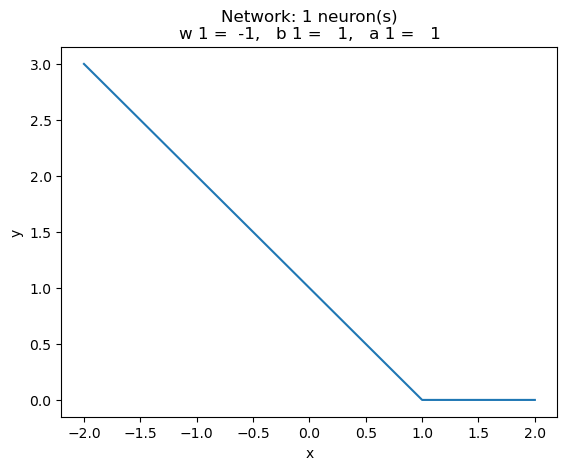

In [29]:
# Shifted mirrored ReLU function
net = SimpleNet(1)
net.W = [-1]
net.B = [1]
net.plot(-2, 2)

If you want to mirror only the direction and not the bending point, the sign of both values needs to be flipped

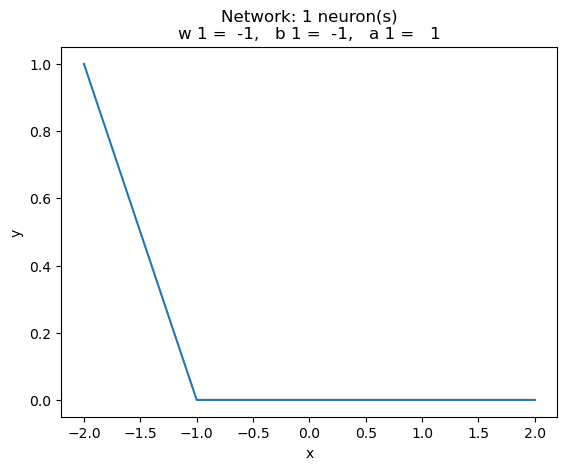

In [30]:
# Shifted mirrored ReLU function
net = SimpleNet(1)
net.W = [-1]
net.B = [-1]
net.plot(-2, 2)

If you want to scale the function without moving the bending point, you need to scale the bias too.

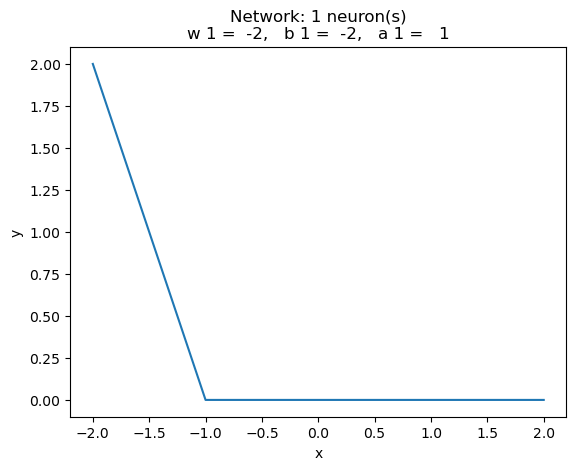

In [31]:
# Shifted mirrored ReLU function
net = SimpleNet(1)
net.W = [-2]
net.B = [-2]
net.plot(-2, 2)

Alternatively, you can scale using a, this also allows you to flip the neuron vertically at once

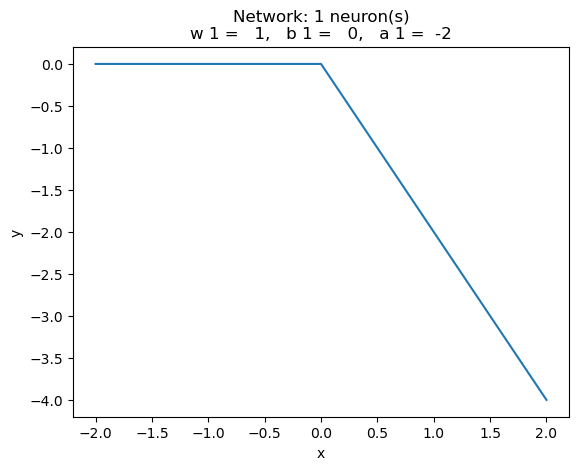

In [32]:
# Shifted mirrored ReLU function
net = SimpleNet(1)
net.A = [-2]
net.plot(-2, 2)

## Transformations

I coded some transformations based on these principles.

In [33]:
class Transformations():

    # Flip i-th ReLU horizontally (in place)
    def flipH(net, i = 1):
        net.W[i - 1] *= -1
        net.B[i - 1] *= -1

    # Flip i-th ReLU vertically (in place)
    def flipV(net, i = 1):
        net.A[i - 1] *= -1

    # Shift i-th ReLU to the right (by s)
    # (if statement accounts for horizontal mirroring)
    def shift(net, s = 0, i = 1):
        net.B[i - 1] -= s * net.W[i - 1]

    # Shift i-th ReLU's bending point to x:
    def shift_to(net, x, i = 1):
        net.B[i - 1] = - x * net.W[i - 1]

    # scale the ReLU by s (in place)
    def scale(net, s = 1, i = 1):
        net.A[i - 1] *= s

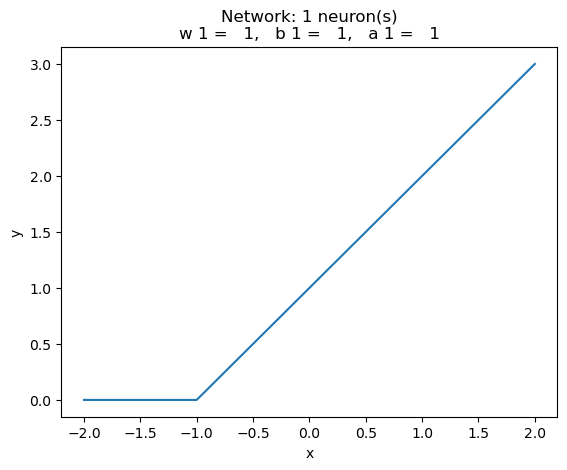

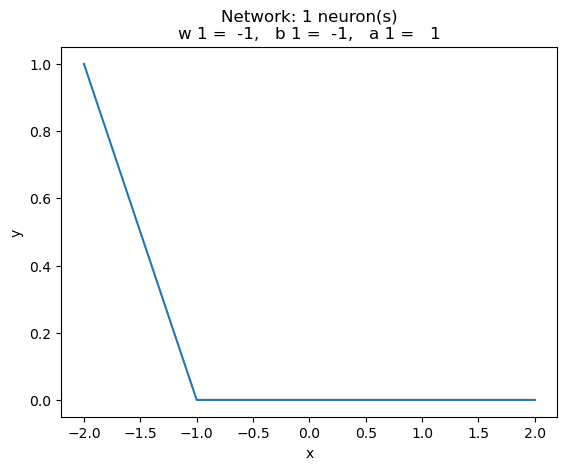

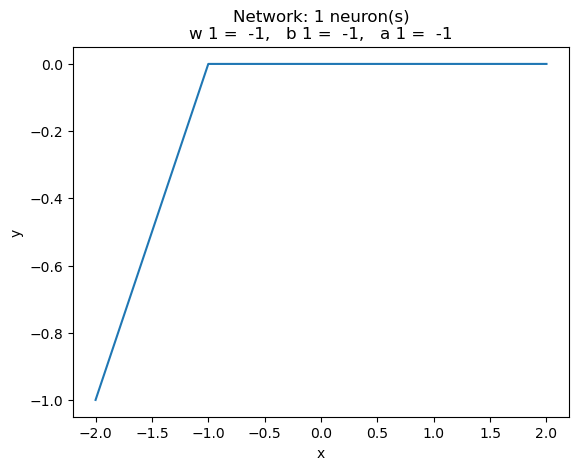

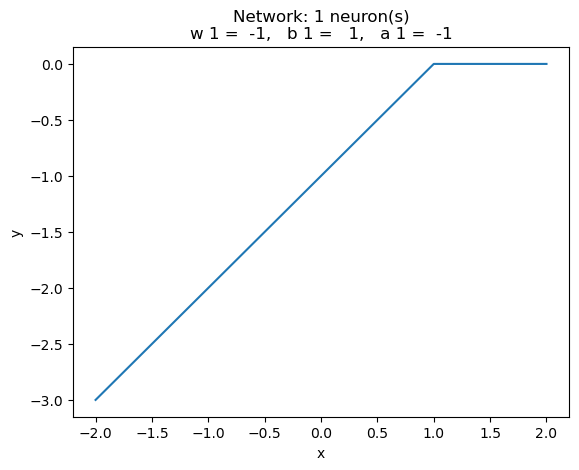

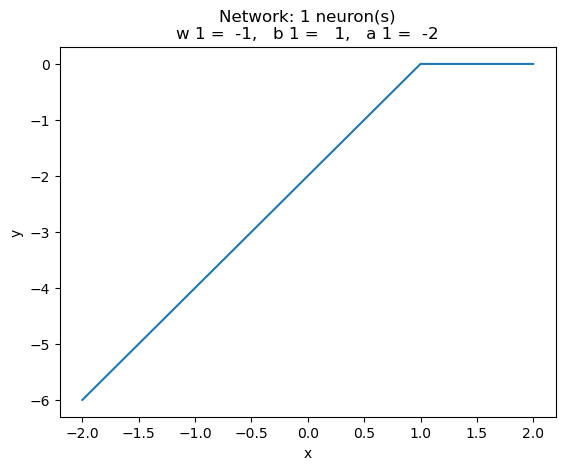

In [34]:
net = SimpleNet(1)

# Shift 1 to the left
Transformations.shift(net, -1)
net.plot(-2, 2)

# Flip horizontally
Transformations.flipH(net)
net.plot(-2, 2)

# Flip vertically
Transformations.flipV(net)
net.plot(-2, 2)

# Shift bending point to 1
Transformations.shift_to(net, 1)
net.plot(-2, 2)

# Scale
Transformations.scale(net, 2)
net.plot(-2, 2)

## Multiple ReLU's

I will use these functions to create a double zigzag from -1 to 1 with an amplitude of 2

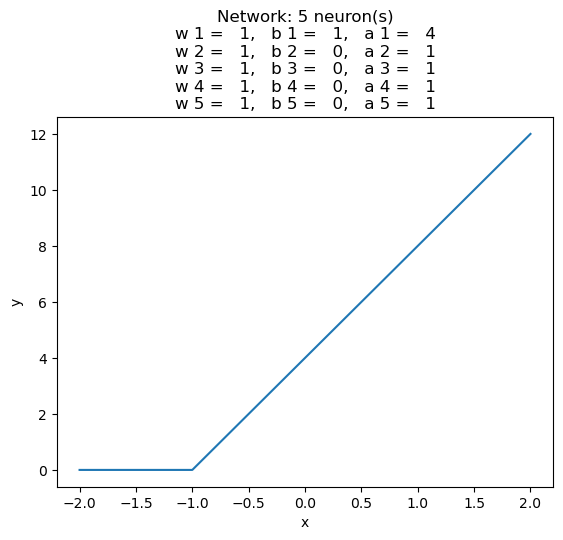

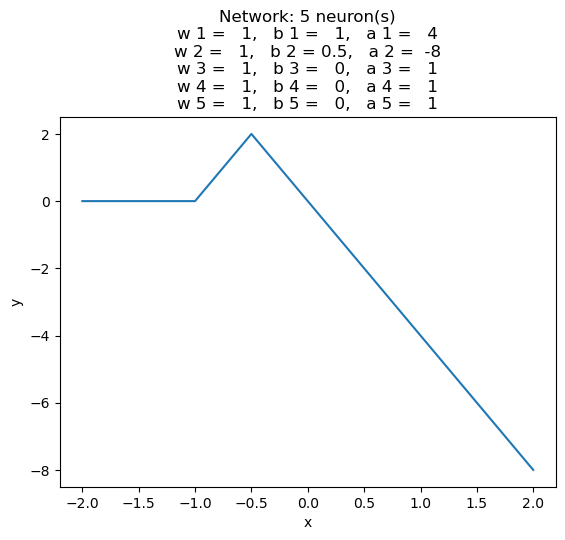

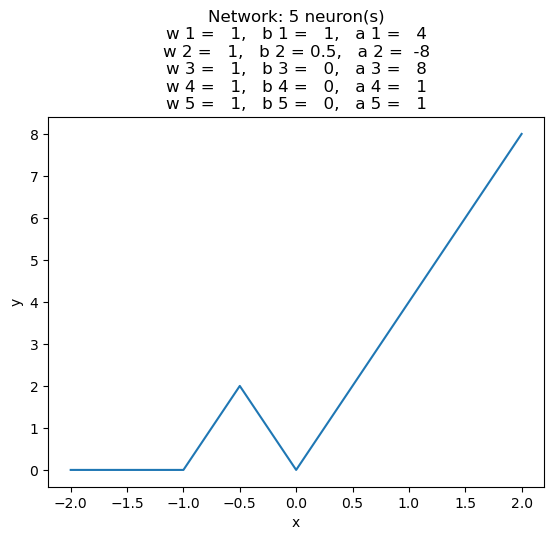

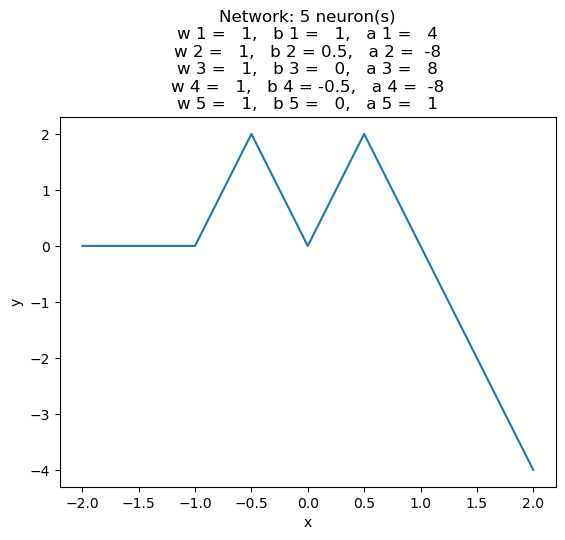

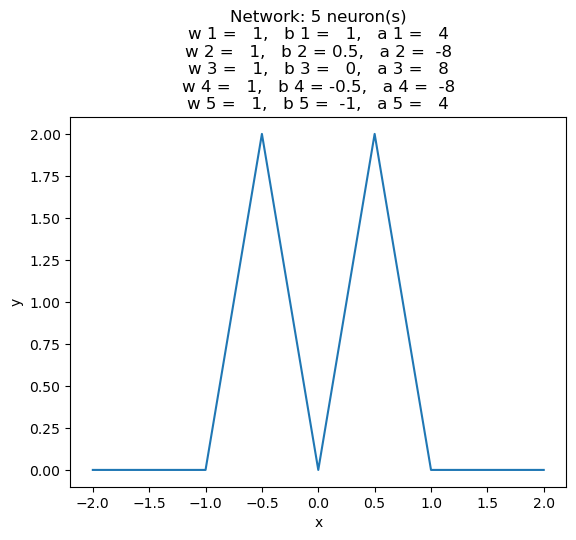

In [35]:
net = SimpleNet(5)

# ReLU 1
Transformations.shift(net,  -1,     i = 1)
Transformations.scale(net,  4,      i = 1)
net.plot(-2, 2, n = 1)

# ReLU 2
Transformations.shift(net,  -0.5,   i = 2)
Transformations.flipV(net,          i = 2)
Transformations.scale(net,  8,      i = 2)
net.plot(-2, 2, n = 2)

# ReLU 3
Transformations.scale(net,  8,      i = 3)
net.plot(-2, 2, n = 3)

# ReLU 4
Transformations.shift(net,  0.5,    i = 4)
Transformations.flipV(net,          i = 4)
Transformations.scale(net,  8,      i = 4)
net.plot(-2, 2, n = 4)

# ReLU 5
Transformations.shift(net,  1,      i = 5)
Transformations.scale(net,  4,      i = 5)
net.plot(-2, 2, n = 5)

## Notes

An optimal zigzag requires:
- A values that alternate in sign
- W values that 'compensate' for other ReLUs

In theory, an algorithm should be able to find an optimal zigzag by:
- shifting ReLUs
- flipping ReLUs (vertically)
- scaling ReLUs

There are multiple possibilities to create optimal zigzags: 
- Scaling can be done both with W and A. 

There are even more possibilities to create suboptimal zigzags:
- ReLU's can be duplicated and stacked
- ReLU's can be duplicated, mirrored and stacked (this creates a V-shape)

## Agglomerate Neurons

It would be interesting to see whether it's possible to 'agglomerate' neurons, instead of simply creating new ones or removing them. 

Say you have 2 ReLU's with identical bending points, you could 'merge' them by finding the right weight and bias to represent their combination in a single ReLU. 

Alternatively it would be cool to find a way to collectively flip signs of neurons, a quick example to illustrate:

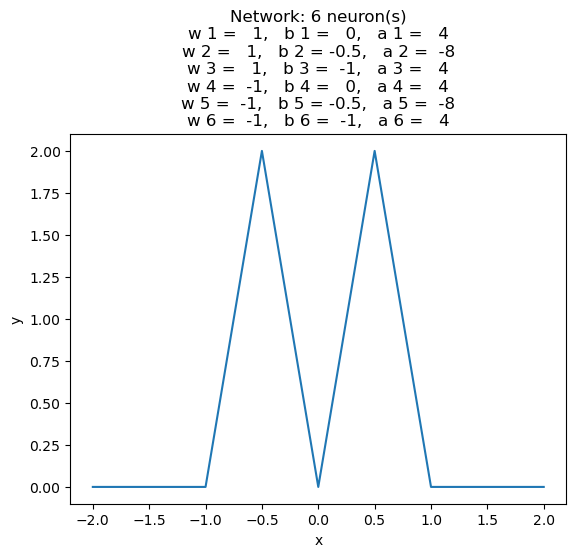

In [43]:
net = SimpleNet(6)

# ReLU 1
Transformations.scale(net, 4,    i = 1)

# ReLU 2
Transformations.shift(net, 0.5,  i = 2)
Transformations.flipV(net,       i = 2)
Transformations.scale(net, 8,    i = 2)

# ReLU 3
Transformations.shift(net, 1,    i = 3)
Transformations.scale(net, 4,    i = 3)

# ReLU 4
Transformations.flipH(net,       i = 4)
Transformations.scale(net, 4,    i = 4)

# ReLU 5
Transformations.flipH(net,       i = 5)
Transformations.shift(net, -0.5, i = 5)
Transformations.flipV(net,       i = 5)
Transformations.scale(net, 8,    i = 5)

# ReLU 6
Transformations.flipH(net,       i = 6)
Transformations.shift(net, -1,   i = 6)
Transformations.scale(net,  4,   i = 6)

net.plot(-2, 2, n = 6)

This zigzag requires 6 ReLU's because it mirrors the last 3 neurons. It could be fixed by going from

```

      /<    >\                    >\    >\
     /  \  /  \                  /  \  /  \
<---<    \/    >--->   to   --->/    >/    \>---

````

Looking at the weights this would be a possibility:
- find mirroring neurons (1, 2, 3) and (4, 5, 6)
- swap the sign of the mirrored neurons
- find their connection (1 and 4)
- agglomerate the connecting neurons

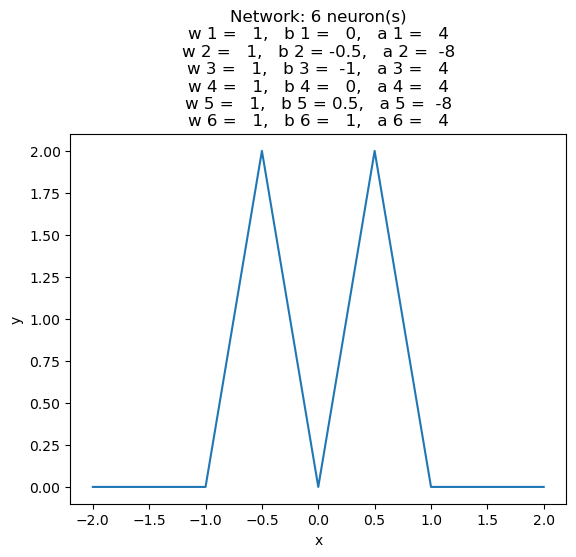

In [44]:
# Flip mirrored neurons
Transformations.flipH(net, i = 4)
Transformations.flipH(net, i = 5)
Transformations.flipH(net, i = 6)

net.plot(-2, 2)

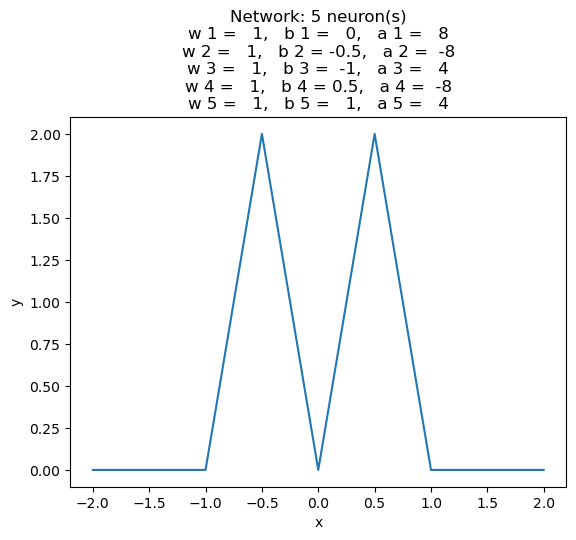

In [45]:
# Get neuron 1 parameters
W1 = net.W[0]
B1 = net.B[0]
A1 = net.A[0]

# Remove Neuron 4
W4 = net.W.pop(3)
B4 = net.B.pop(3)
A4 = net.A.pop(3)
net.N -= 1

# Agglomerate neurons
net.W[0] = 1
net.B[0] = B1 + B4
net.A[0] = A1 + A4

net.plot(-2, 2)

# Final Implementation

With these principles I will create 'Final' classes that could serve as a blueprint for our experiments

## Neuron Class

Explanation:

In [143]:
class Neuron():

    # === Standard Functions ===

    # Initialise Parameters
    def __init__(self, w = 1, b = 0, a = 1):
        self.w, self.b, self.a = w, b, a

    # Forward pass (ReLU)
    def __call__(self, x):
        return self.a * max(0, self.w * x + self.b)

    # Compares bending coordinates
    def __lt__(self, other):
        return self.b / self.w > other.b / other.w
    
    # Equates bending coordinates
    def __eq__(self, other):
        return self.b / self.w == other.b / other.w
    
    # String representation
    def __str__(self):
        return f"Neuron:   w = {self.w:3},   b = {self.b:3},   a = {self.a:3}"
    
    # Plot network for specified range
    def plot(self, start = -10, stop = 10, res = 10):

        # Calculate values for range
        x = np.linspace(start, stop, abs(start) * res + abs(stop) * res + 1)
        y = [self(x) for x in x]
        
        # Plot graph
        plt.figure()
        plt.plot(x, y)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(str(self))
        plt.show()



    # === Transformations ===

    # Flip neuron horizontally (in place)
    def fliph(self):
        self.w, self.b = self.w * -1, self.b * -1

    # Flip neuron vertically (in place)
    def flipv(self):
        self.a *= -1

    # Shift neuron s to the right
    def shift(self, s):
        self.b -= s * self.w

    # Shift neurons bending point to x
    def shift_to(self, x):
        self.b = - x * self.w

    # scale neuron in place (by s)
    def scale(self, s):
        self.a *= s

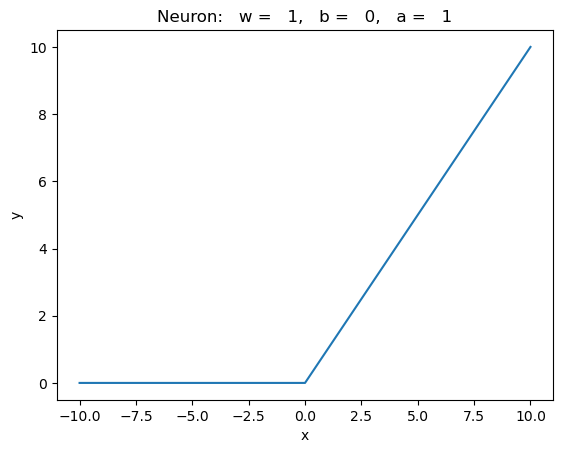

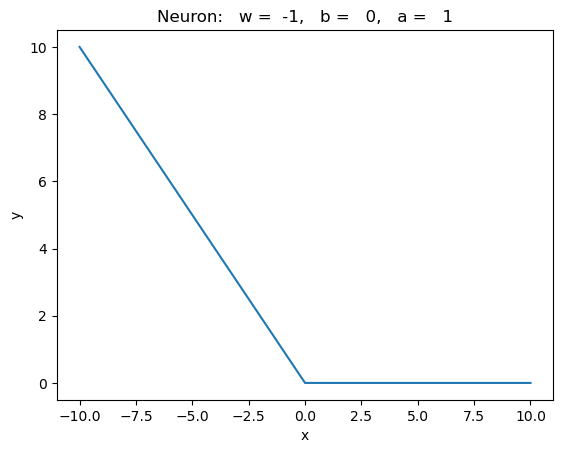

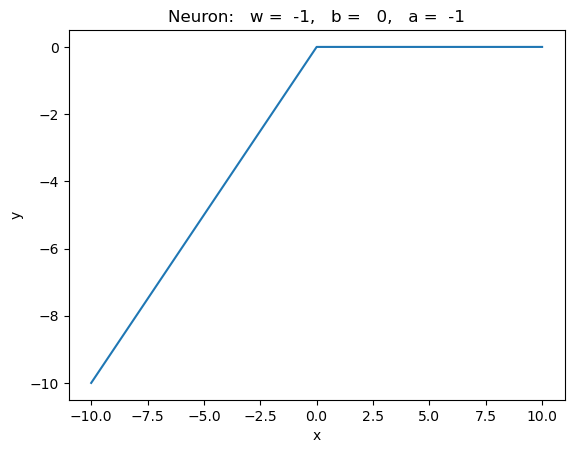

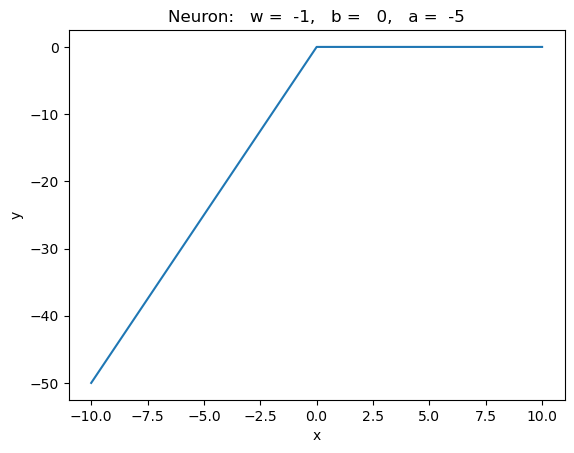

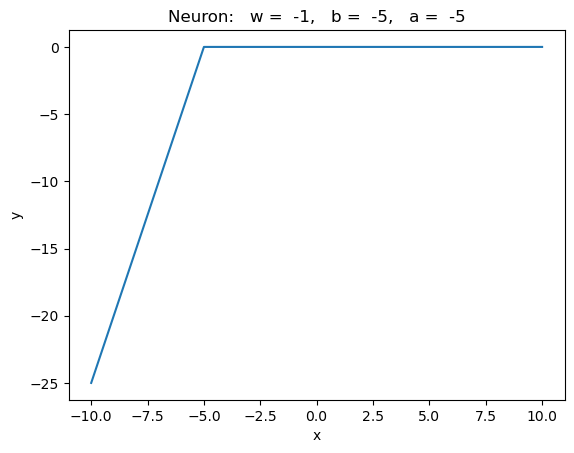

In [144]:
# Quick test
neuron = Neuron()
neuron.plot()

neuron.fliph()
neuron.plot()

neuron.flipv()
neuron.plot()

neuron.scale(5)
neuron.plot()

neuron.shift(-5)
neuron.plot()

## Agglomeration

I need to figure out a way to agglomerate neurons that don't stack

### First Try

There should be some conditions:
- Neurons should be 'close together' (meaning that bending points are close)
- Neurons should have somewhat similar directions (you would not agglomerate 2 zigzagging neurons)

Formally:
- n1    = a1 * max(0, w1 * x + b1)
- n2    = a2 * max(0, w2 * x + b2)
- n1&2  = a1 * max(0, w1 * x + b1) + a2 * max(0, w2 * x + b2)

To agglomerate neurons, we approximate their combination with a single ReLU.
- assume that x > bending point
- n1&2  = a1 * (w1 * x + b1) + a2 * (w2 * x + b2)
- n1&2  = a1 * w1 + x + a1 * b1 + a2 * w2 * x + a2 * b2
- n1&2  = (a1 * w1 + a2 * w2) * x + a1 * b1 + a2 * b2
- For the new neuron: w = (a1 * w1 + a2 * w2), b = a1 * b1 + a2 * b2

a:
- w already accounts for a in the slope
- however, if it is a negative value, it will be mirrored instead of flipped
- if w > 0: a = 1
- if w < 0: a = -1, flip sign of w and b

In [145]:
def agglomerate(n1, n2):

    # Extract values
    w1, b1, a1 = n1.w, n1.b, n1.a
    w2, b2, a2 = n2.w, n2.b, n2.a

    # Calculate w
    w = a1 * w1 + a2 * w2

    # Calculate b
    b = (b1 * a1 + b2 * a2)
    
    # Adjust w, set a
    if w > 0:
        a = 1
    elif w < 0:
        w *= -1
        b *= -1
        a = -1

    # Return agglomeration
    return Neuron(w, b, a)

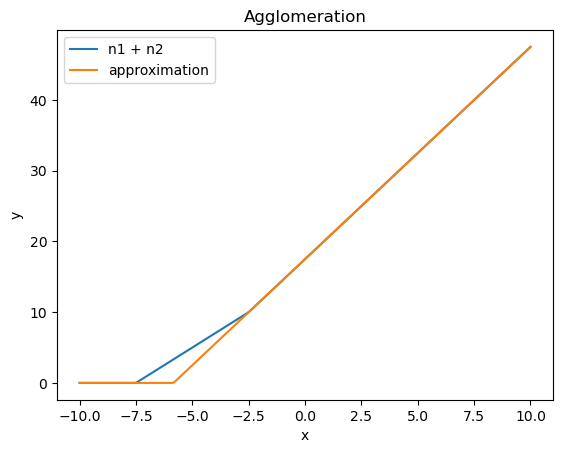

In [146]:
# Test

# Initialise x-range
x = np.linspace(-10, 10, 200)

# Initialise neurons
n1 = Neuron()
n2 = Neuron()
n1.shift(-7.5)
n2.shift(-2.5)
n1.scale(2)
#n2.flipv()

# Agglomerate neurons
n12 = agglomerate(n1, n2)

# Plot graph
plt.figure()
plt.plot(x, [n1(x) + n2(x) for x in x], label = 'n1 + n2')
plt.plot(x, [n12(x) for x in x], label = 'approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Agglomeration')
plt.legend()
plt.show()

### Second Try

This is not quite what im after, let's try something else:
- find the bending points of neuron 1 and 2 and sort the in order
- before bending point 1: slope = 0
- from bending point 1 till 2: slope = w1 * a1
- from bending point onward: slope = w1 * a1 + w2 * a2
- slope appromximation: mean between the two (2 * (w1 + a1) + w2 * a2) / 2
- if bending points are equal, the slope should be w1 + a1 + w2 * a2
- same adjustment for a when w < 0

In [160]:
def agglomerate(n1, n2):

    # Sort neurons
    if n1 > n2:
        n1, n2 = n2, n1

    # Extract values
    w1, b1, a1 = n1.w, n1.b, n1.a
    w2, b2, a2 = n2.w, n2.b, n2.a

    # Calculate w
    if n1 == n2:
        w = a1 * w1 + a2 * w2
    else:
        w = (2 * (a1 * w1) + a2 * w2) / 2

    # Calculate b
    b = (b1 * a1 + b2 * a2)
    
    # Set a, adjust w and b if necessary
    if w >= 0:
        a = 1
    elif w < 0:
        w *= -1
        b *= -1
        a = -1

    # Return agglomeration
    return Neuron(w, b, a)

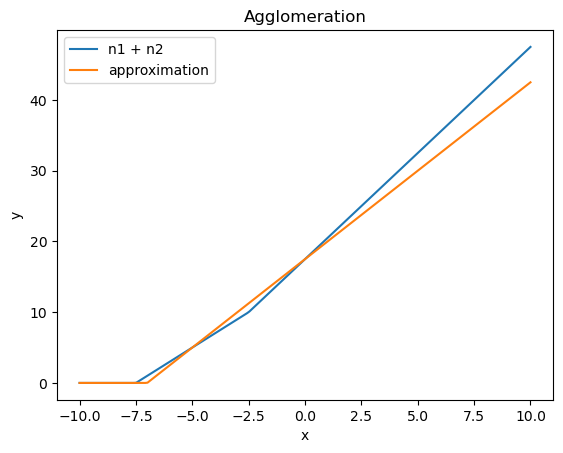

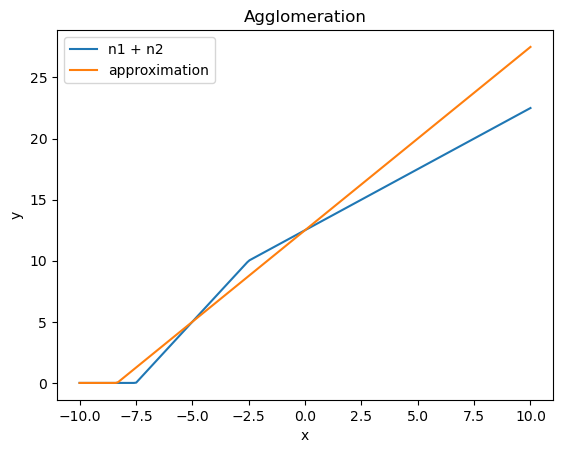

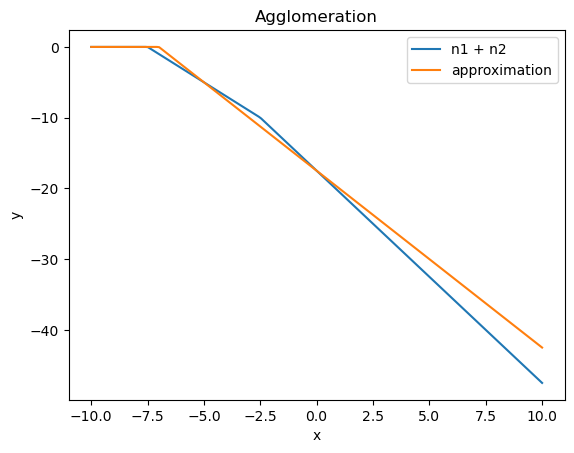

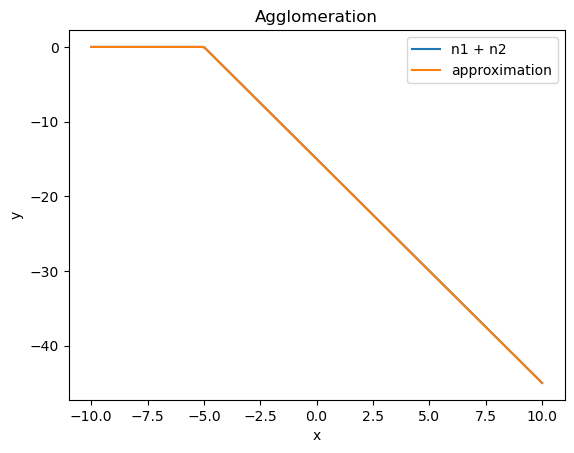

In [161]:
# Test

# Initialise x-range
x = np.linspace(-10, 10, 200)

# Initialise neurons
n1 = Neuron()
n2 = Neuron()
n1.shift(-7.5)
n2.shift(-2.5)
n1.scale(2)

# Agglomerate neurons
n12 = agglomerate(n1, n2)

# Plot graph
plt.figure()
plt.plot(x, [n1(x) + n2(x) for x in x], label = 'n1 + n2')
plt.plot(x, [n12(x) for x in x], label = 'approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Agglomeration')
plt.legend()
plt.show()

# Test 2 

n2.flipv()

# Agglomerate neurons
n12 = agglomerate(n1, n2)

# Plot graph
plt.figure()
plt.plot(x, [n1(x) + n2(x) for x in x], label = 'n1 + n2')
plt.plot(x, [n12(x) for x in x], label = 'approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Agglomeration')
plt.legend()
plt.show()

# Test 3

n1.flipv()

# Agglomerate neurons
n12 = agglomerate(n1, n2)

# Plot graph
plt.figure()
plt.plot(x, [n1(x) + n2(x) for x in x], label = 'n1 + n2')
plt.plot(x, [n12(x) for x in x], label = 'approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Agglomeration')
plt.legend()
plt.show()

# Test 4

n1.shift(2.5)
n2.shift(-2.5)

# Agglomerate neurons
n12 = agglomerate(n1, n2)

# Plot graph
plt.figure()
plt.plot(x, [n1(x) + n2(x) for x in x], label = 'n1 + n2')
plt.plot(x, [n12(x) for x in x], label = 'approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Agglomeration')
plt.legend()
plt.show()

## EvoNet Class

In [ ]:
class EvoNet():

    # === Standard Functions ===

    # Initialise network
    def __init__(self, N):
        self.N = N
        self.hidden = [Neuron() for _ in range(N)]

    # Forward function
    def __call__(self, x, n = None):
        n = self.N if n is None else n
        return sum([neuron(x) for neuron in self.hidden[:n]])
    
    # String representation
    def __str__(self):

        string = f"Network (Hidden = {self.N})"
        for i in range(self.N):
            string += f"\n({i + 1}) {self.hidden[i]}"

        return string
    
    # Plot network for specified range
    # Optional n to only plot first n neurons
    def plot(self, start = -10, stop = 10, n = None, res = 10):

        # Calculate values for range
        x = np.linspace(start, stop, abs(start) * res + abs(stop) * res + 1)
        y = [self(point, n) for point in x]
        
        # Plot graph
        plt.figure()
        plt.plot(x, y)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(str(self))
        plt.show()

    # Sort the neurons based on their bending points
    def sort(self):
        self.hidden = sorted(self.hidden)

    

    # === Transformations ===

    # Flip neuron horizontally (in place)
    def fliph(self, i):
        self.hidden[i - 1].fliph()

    # Flip neuron vertically (in place)
    def flipv(self, i):
        self.hidden[i - 1].flipv()

    # Shift neuron s to the right
    def shift(self, s, i):
        self.hidden[i - 1].shift(s)
        self.sort()

    # Shift neurons bending point to x
    def shift_to(self, x, i):
        self.hidden[i - 1].shift_to(x)
        self.sort()

    # scale neuron in place (by s)
    def scale(self, s, i):
        self.hidden[i - 1].scale(s)

    

    # === Agglomeration
    
    # agglomerate neuron i and j
    def agglomerate(self, i, j):

        # Remove neurons (they are sorted)
        n2 = self.hidden.pop(j - 1)
        n1 = self.hidden.pop(i - 1) if i < j else self.hidden.pop(i - 2)

        # Extract values
        w1, b1, a1 = n1.w, n1.b, n1.a
        w2, b2, a2 = n2.w, n2.b, n2.a

        # Calculate w
        if n1 == n2:
            w = a1 * w1 + a2 * w2
        else:
            w = (2 * (a1 * w1) + a2 * w2) / 2

        # Extract parameters
        w1, b1, a1 = n1.w, n1.b, n1.a
        w2, b2, a2 = n2.w, n2.b, n2.a

        # Calculate w
        w = (2 * (a1 * w1) + a2 * w2) / 2

        # Calculate b
        b = (b1 * a1 + b2 * a2)
        
        # Adjust w, set a
        if w > 0:
            a = 1
        elif w < 0:
            w *= -1
            b *= -1
            a = -1

        # Agglomerate
        combined = Neuron(w, b, a)

        # Add to hidden
        self.hidden.append(combined)
        self.sort()

        # Update size
        self.N -= 1

## EA Building Blocks

I haven't had the time to fully implement everything, so here are my thoughts:

### Representation

The representation is largely self explanatory: a neural network consisting of ReLU's.

I think a useful addition would be to sort the ReLU's based on their bending points. This has a few advantages:
- Easily find adjecent neurons to merge
- Easily define 'halves' for crossover

### Crossover

Since a (potential) zigzag consists of neurons 'compensating' for each other's slope in sequence from left to right, I think it would make sense to do the following:
- For each network, find their range of bending points
- Pick a random number in the overlap of these ranges
- Cut the networks in 2 halves according to this point
- Swap 2 of the halves

This should allow good approximations to pass on a part of their zigzag, regardless of how many stacked neurons are contributing.

### Parameters Mutation

For mutation I have explored several ideas. Each of the parameters changes the shape of the ReLU. However, it's important to keep in mind that backprop can change each of these parameters. Therefore, basic operations like scaling and shifting are probably redundant. It's more interesting to look at mutations that can complement backpropagation. 

**Vertically flip neuron (a *= -1)**: Technically backprop can do this, however, it only takes small steps, so it's probably unlikely that it will flip a neuron entirely. Therefore, it might be helpful to add this functionality in the shape of mutation. We could change the probability depending on adjacent neurons (say a neuron and its neigbours all have positive a values, then the neuron should probably flip). However, I'm not sure whether we should increase odds of this happening, or incentivise it indirectly with the fitness function.

**Switch neurons to same sign (w)**: It has been established that an optimal zigzag requires ReLU's to point in the same direction (horizontally). Therefore, it might be worthwhile to add a mutation for this. Again, backprop can do this technically, but it is unlikely that it will do this. For this you would want to flip the direction of the minority to match that of the rest. I should note that I haven't extensively explored the effect of flipping neurons horizontally in a zizag. It just happened to work out in the example.

### Topology Mutation

This is probably the most interesting and worthwhile addition. 

**Agglomeration** With many neurons (like a 100) a network can is able to find the function, however, many neurons tend to converge to the same bending point. Agglomeration would provide the perfect solution to solve this 'redundancy'. 

A few things to keep in mind:
- Only adjecant neurons should be agglomerated
- Neurons that are closer by (in terms of bending point) should have a higher probability of merging (100% probability for overlapping neurons?)
- neurons with very dissimilar slopes (w * a) should have a low probability of merging (You don't want zigzagging neurons to merge)

**Adding neurons** I haven't really thought about this one yet. The main question is how can you best initialise a neuron's w, b and a parameters.

### Fitness

I don't know what metric is most suitable, maybe MSE? Additionally, it could be worthwhile to add a term that penalises a number of neurons that is much larger than the optimal amount of neurons. It could also be worthwhile to add a term that favours alternating signs of a values (since this is required for a zigzag to occur).

### Experiments

I have 2 suggestions:
- With the operations I implemented (i.e. shift, flipv, scale) and EA should technically be able to find the solution. It might be worthwhile to test this scenario using ONLY EA.
- For the hybrid scenario, we could see whether the addition of backpropagation improves convergence speed (like the assignment)
